[*********************100%***********************]  10 of 10 completed


Optimal Alpha (Lambda): 0.000132


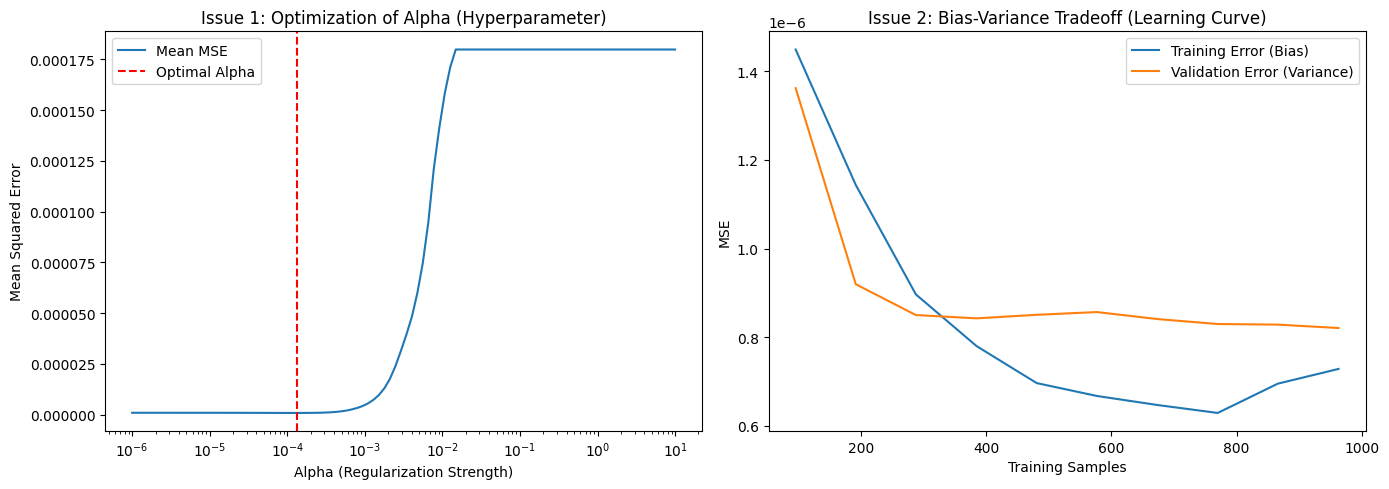

Test R-Squared: 0.9738
Test MSE: 0.000004


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Corrected Data Acquisition
tickers = ['SPY', 'XLK', 'XLF', 'XLV', 'XLP', 'XLY', 'XLI', 'XLC', 'XLU', 'XLE']
# We fetch 'Close' and set auto_adjust=True to get adjusted prices reliably
raw_data = yf.download(tickers, start="2020-01-01", end="2025-12-31", auto_adjust=True)

# Handle MultiIndex: Extract only the 'Close' column group
data = raw_data['Close'] 

# 2. Calculate Daily Returns
returns = data.pct_change().dropna()
y = returns['SPY']
X = returns.drop(columns=['SPY'])

# 3. Split Data: Chronological split for financial time-series [cite: 16]
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Standardization [cite: 188, 195]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Issue 1: Hyperparameter Optimization (LassoCV) [cite: 13, 14, 214]
alphas = np.logspace(-6, 1, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha (Lambda): {lasso_cv.alpha_:.6f}")

# 6. Issue 2: Bias-Variance Tradeoff (Learning Curve) 
train_sizes, train_scores, test_scores = learning_curve(
    Lasso(alpha=lasso_cv.alpha_), X_train_scaled, y_train, 
    cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mse = -np.mean(train_scores, axis=1)
test_mse = -np.mean(test_scores, axis=1)

# --- Visualizations ---
plt.figure(figsize=(14, 5))

# Plot A: Hyperparameter Path [cite: 213, 602]
plt.subplot(1, 2, 1)
mse_path = lasso_cv.mse_path_.mean(axis=1)
plt.semilogx(lasso_cv.alphas_, mse_path, label='Mean MSE')
plt.axvline(lasso_cv.alpha_, linestyle='--', color='r', label='Optimal Alpha')
plt.title('Issue 1: Optimization of Alpha (Hyperparameter)')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.legend()

# Plot B: Bias-Variance Learning Curve [cite: 17, 18, 603]
plt.subplot(1, 2, 2)
plt.plot(train_sizes, train_mse, label='Training Error (Bias)')
plt.plot(train_sizes, test_mse, label='Validation Error (Variance)')
plt.title('Issue 2: Bias-Variance Tradeoff (Learning Curve)')
plt.xlabel('Training Samples')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()

# Final Evaluation [cite: 212]
y_pred = lasso_cv.predict(X_test_scaled)
print(f"Test R-Squared: {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.6f}")

                     Model  R-Squared       MSE
0         Individual LASSO   0.973790  0.000004
1  Random Forest (Bagging)   0.948823  0.000007
2    Stacking (Lasso + NN)   0.841757  0.000021


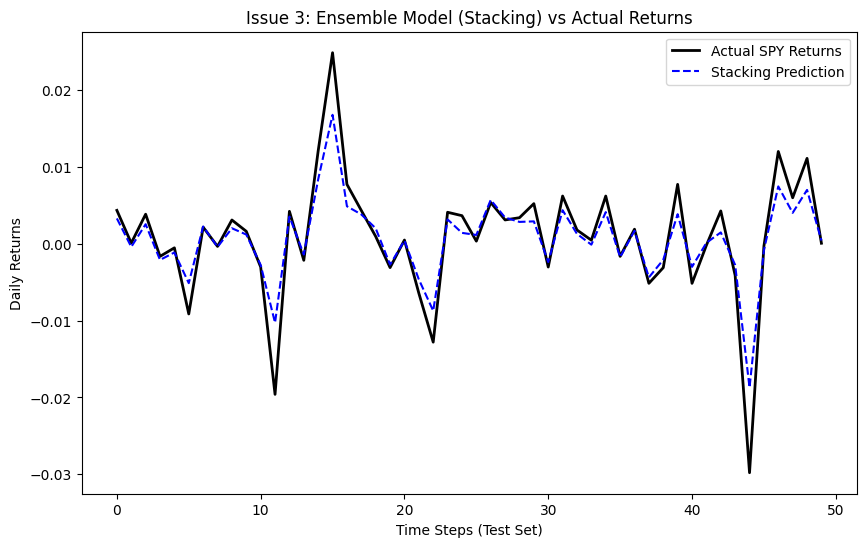

In [3]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import RidgeCV

# 1. Homogeneous Ensemble: Bagging (Random Forest)
# Random Forest uses multiple decision trees to reduce variance.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# 2. Heterogeneous Ensemble: Stacking
# We combine LASSO (from Issue 1) and Neural Network (from Project 2)
# We use a Ridge model as the 'Final Estimator' to blend the predictions.
estimators = [
    ('lasso', Lasso(alpha=lasso_cv.alpha_)),
    ('nn', MLPRegressor(hidden_layer_sizes=(20, 10), activation='relu', solver='adam', max_iter=2000, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

stacking_model.fit(X_train_scaled, y_train)
stack_pred = stacking_model.predict(X_test_scaled)

# 3. Performance Comparison
results = pd.DataFrame({
    'Model': ['Individual LASSO', 'Random Forest (Bagging)', 'Stacking (Lasso + NN)'],
    'R-Squared': [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, stack_pred)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, stack_pred)
    ]
})

print(results)

# --- Visualization: Prediction Comparison ---
plt.figure(figsize=(10, 6))
plt.plot(y_test.values[:50], label='Actual SPY Returns', color='black', linewidth=2)
plt.plot(stack_pred[:50], label='Stacking Prediction', linestyle='--', color='blue')
plt.title('Issue 3: Ensemble Model (Stacking) vs Actual Returns')
plt.xlabel('Time Steps (Test Set)')
plt.ylabel('Daily Returns')
plt.legend()
plt.show()